In [9]:
import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from model import get_model
from forward_operator import get_operator
from sampler import get_sampler


In [10]:
# Load model config (ddpm)
model_cfg_path = 'configs/model/ffhq256ddpm.yaml'
model_cfg = OmegaConf.load(model_cfg_path)
model = get_model(**model_cfg).cuda()
model.eval()

# Load task/operator config
task_cfg_path = 'configs/task/phase_retrieval.yaml'
task_cfg = OmegaConf.load(task_cfg_path)

# Use pixel-space box inpainting
pixel_cfg = task_cfg.pixel
operator_cfg = pixel_cfg.operator
mcmc_cfg = pixel_cfg.mcmc_sampler_config

print("Operator config:", operator_cfg)
print("MCMC config:", mcmc_cfg)



Operator config: {'name': 'phase_retrieval', 'oversample': 2.0, 'sigma': 0.05}
MCMC config: {'num_steps': 100, 'lr': 5e-05, 'tau': 0.01, 'lr_min_ratio': 0.01, 'mc_algo': 'langevin', 'prior_solver': 'gaussian'}


In [11]:
#Load a dataset using a config file
from data import get_dataset
dataset_config_yaml = 'configs/data/ffhq.yaml'
dataset_config = OmegaConf.load(dataset_config_yaml)
dataset = get_dataset(**dataset_config)
images = dataset.get_data(5)

In [12]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images,title = "image", target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target,title, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target,title, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(24, 24))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.title(title)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()


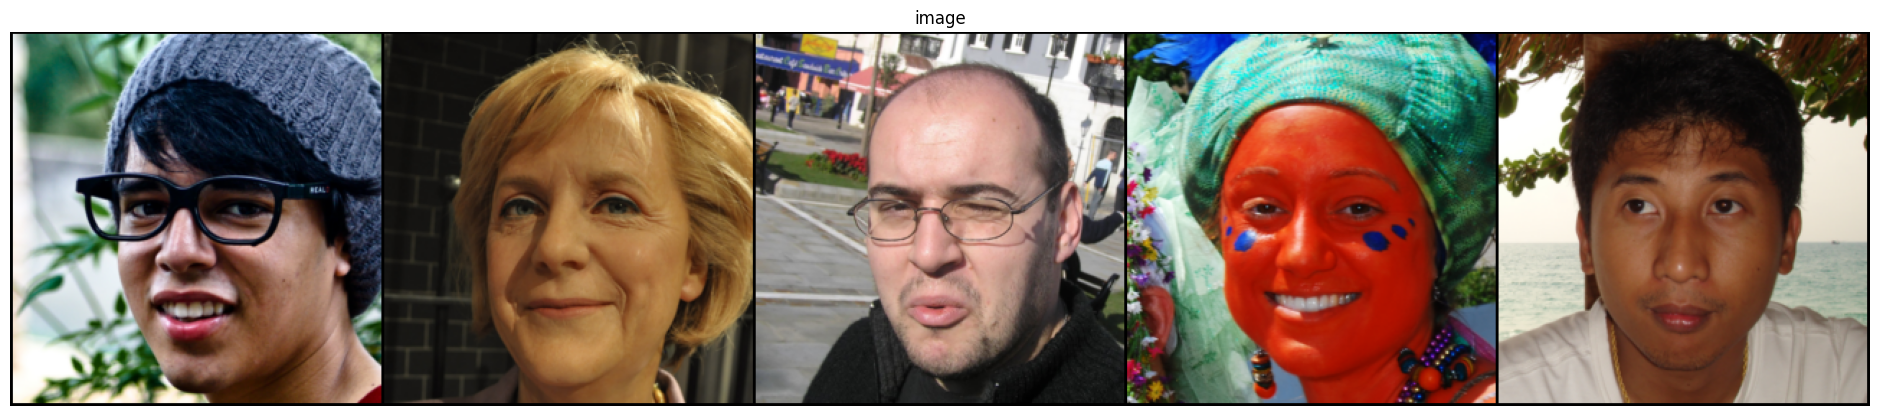

In [13]:
visualize_grid(images, nrow=10)

### DAPS Evaluation

In [14]:
operator = get_operator(**operator_cfg)
y = operator.measure(images)
# mask = operator.mask       # mask generated inside the operator

In [15]:
# Load sampler YAML
sampler_cfg_path = "configs/sampler/edm_daps.yaml"
sampler_cfg = OmegaConf.load(sampler_cfg_path)

# Construct sampler
sampler = get_sampler(
    latent=sampler_cfg.latent,
    annealing_scheduler_config=sampler_cfg.annealing_scheduler_config,
    diffusion_scheduler_config=sampler_cfg.diffusion_scheduler_config,
    mcmc_sampler_config=mcmc_cfg  # from pixel/inpainting config
)

# DAPS requires a starting point
x_start = sampler.get_start(batch_size=5, model=model)
# Run DAPS
# with torch.no_grad():
daps_result = sampler.sample(
        model=model,
        x_start=x_start,
        operator=operator,
        measurement=y,
        verbose=True
    )

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [10:10<00:00,  3.05s/it]


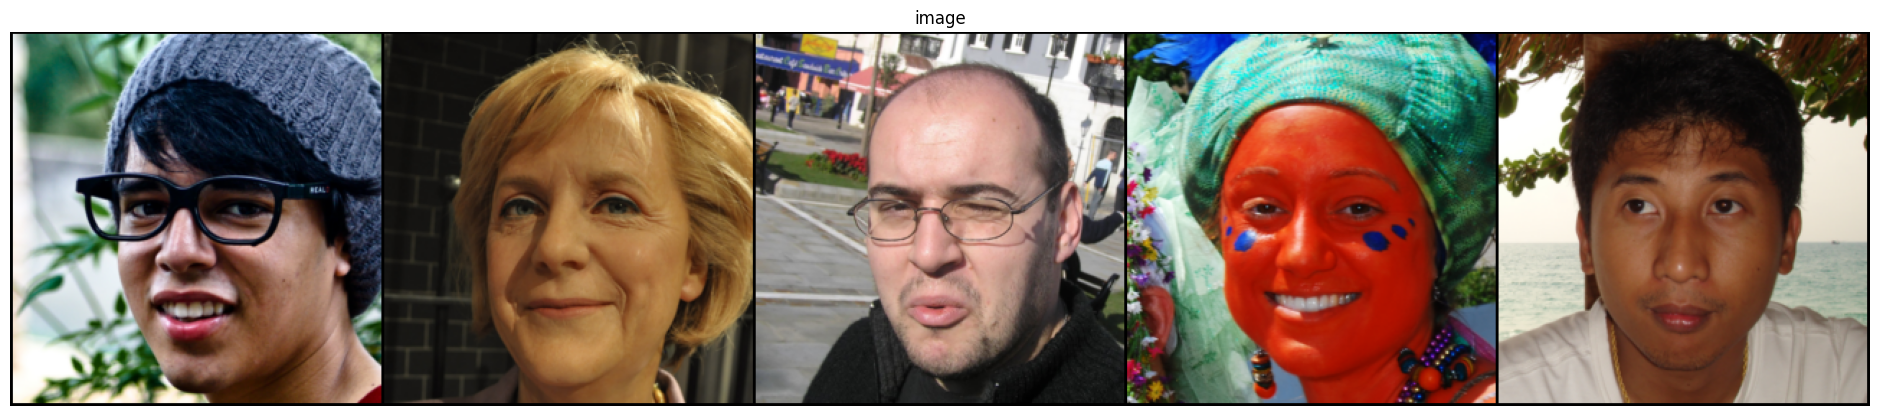

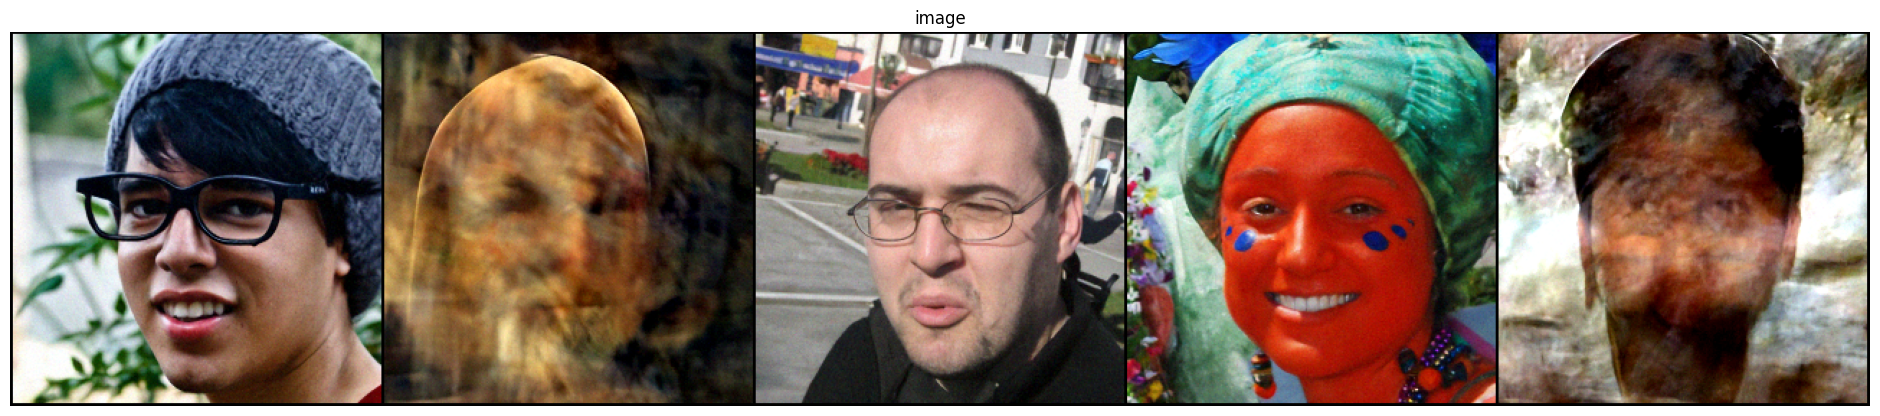

In [16]:
visualize_grid(images, nrow=10)
visualize_grid(daps_result, nrow=10)

In [17]:
def inspect_tensor(name, x):
    print(f"\n{name}:")
    print("  shape: ", x.shape)
    print("  dtype: ", x.dtype)
    print("  device:", x.device)
    print("  min:   ", x.min().item())
    print("  max:   ", x.max().item())
    print("  mean:  ", x.mean().item())

inspect_tensor("Ground Truth", images)
inspect_tensor("DAPS Output", daps_result)



Ground Truth:
  shape:  torch.Size([5, 3, 256, 256])
  dtype:  torch.float32
  device: cuda:0
  min:    -1.0
  max:    1.0
  mean:   -0.19733384251594543

DAPS Output:
  shape:  torch.Size([5, 3, 256, 256])
  dtype:  torch.float32
  device: cuda:0
  min:    -1.3407902717590332
  max:    1.2711992263793945
  mean:   -0.1972014158964157


In [18]:
daps_norm = norm_image_01(daps_result)
gt_norm   =  norm_image_01(images)


In [19]:
def inspect_tensor(name, x):
    print(f"\n{name}:")
    print("  shape: ", x.shape)
    print("  dtype: ", x.dtype)
    print("  device:", x.device)
    print("  min:   ", x.min().item())
    print("  max:   ", x.max().item())
    print("  mean:  ", x.mean().item())

inspect_tensor("Ground Truth", gt_norm)
inspect_tensor("DAPS Output", daps_norm)



Ground Truth:
  shape:  torch.Size([5, 3, 256, 256])
  dtype:  torch.float32
  device: cuda:0
  min:    0.0
  max:    1.0
  mean:   0.40133312344551086

DAPS Output:
  shape:  torch.Size([5, 3, 256, 256])
  dtype:  torch.float32
  device: cuda:0
  min:    0.0
  max:    1.0
  mean:   0.4019823372364044


In [20]:
from piq import psnr, ssim, LPIPS

In [21]:
# PSNR 
psnr_value = psnr(gt_norm, daps_norm, data_range=1.0, reduction='mean')
print("PSNR:", psnr_value.item())

# SSIM
ssim_value = ssim(gt_norm, daps_norm, data_range=1.0, reduction='mean')
print("SSIM:", ssim_value.item())

# LPIPS 
lpips_fn = LPIPS(replace_pooling=True, reduction='mean')  #replace_pooling =True, suggested by LPIPS paper
lpips_value = lpips_fn(gt_norm, daps_norm)
print("LPIPS:", lpips_value.item())

PSNR: 21.997772216796875
SSIM: 0.6028356552124023


/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


LPIPS: 0.32474932074546814


In [22]:

from torch.utils.data import DataLoader, TensorDataset
from piq import FID

def collate_dict(batch):
    images = torch.stack([b[0] for b in batch], dim=0)
    return {'images': images}

batch_size = 5
gt_dataset = TensorDataset(gt_norm)
daps_dataset = TensorDataset(daps_norm)

gt_dl = DataLoader(gt_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dict)
daps_dl = DataLoader(daps_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dict)


fid_metric = FID().to(gt_norm.device)
gt_feats = fid_metric.compute_feats(gt_dl)
daps_feats = fid_metric.compute_feats(daps_dl)

fid_value = fid_metric(gt_feats, daps_feats)

print("FID Score =", fid_value.item())


/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


FID Score = 288.9778631073775


In [24]:
import torch
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights
from piq import FID

def preprocess(images):
    # Resize for Inception
    images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
    
    # Convert [-1,1] → [0,1]
    images = images * 0.5 + 0.5
    
    # ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
    images = (images - mean) / std
    return images.float()


def get_features(dataloader, model, device):
    feats = []
    for batch in dataloader:
        batch = preprocess(batch).to(device)
        with torch.no_grad():
            out = model(batch)
        feats.append(out.cpu())
    return torch.cat(feats, dim=0)


def compute_fid(real_loader, fake_loader, device="cuda"):
    # Load pretrained InceptionV3 properly
    model = inception_v3(pretrained=True)
    model.fc = torch.nn.Identity()  
    model.to(device)
    model.eval()

    real_features = get_features(real_loader, model, device)
    fake_features = get_features(fake_loader, model, device)

    fid = FID()
    score = fid.compute_metric(real_features, fake_features)
    return score.item()


In [25]:
from torch.utils.data import DataLoader

real_loader = DataLoader(gt_norm, batch_size=5)
fake_loader = DataLoader(daps_norm, batch_size=5)

fid = compute_fid(real_loader, fake_loader)
print("FID:", fid)


/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FID: 279.8274325700811


So we are getting somwhat different results from the above two one is directly from piq library and other is from DAPS, evaluate_fid.py. The reason could be in piq library internal model version is differnt(v2 instead of v3) and resizing and normalization might be differnt not sure. So to verify their results its better to use DAPS

## Our Sampler

In [26]:
from main.scheduler import EDMScheduler
num_steps = 5
edmsampler1 = EDMScheduler(num_steps)
img1 = images[0]
img1.shape
(5, *img1.shape)
tuple(images.shape)


(5, 3, 256, 256)

In [28]:

from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (5, *img1.shape))

In [29]:
from daps_sampler import DAPS
daps = DAPS(sampler_cfg['annealing_scheduler_config'], sampler_cfg['diffusion_scheduler_config'], mcmc_cfg)
x_init = pf_ode.gaussian_prior_x_T(5)
x_final = daps.daps_sample(model, x_init, operator, y)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [10:10<00:00,  3.05s/it]


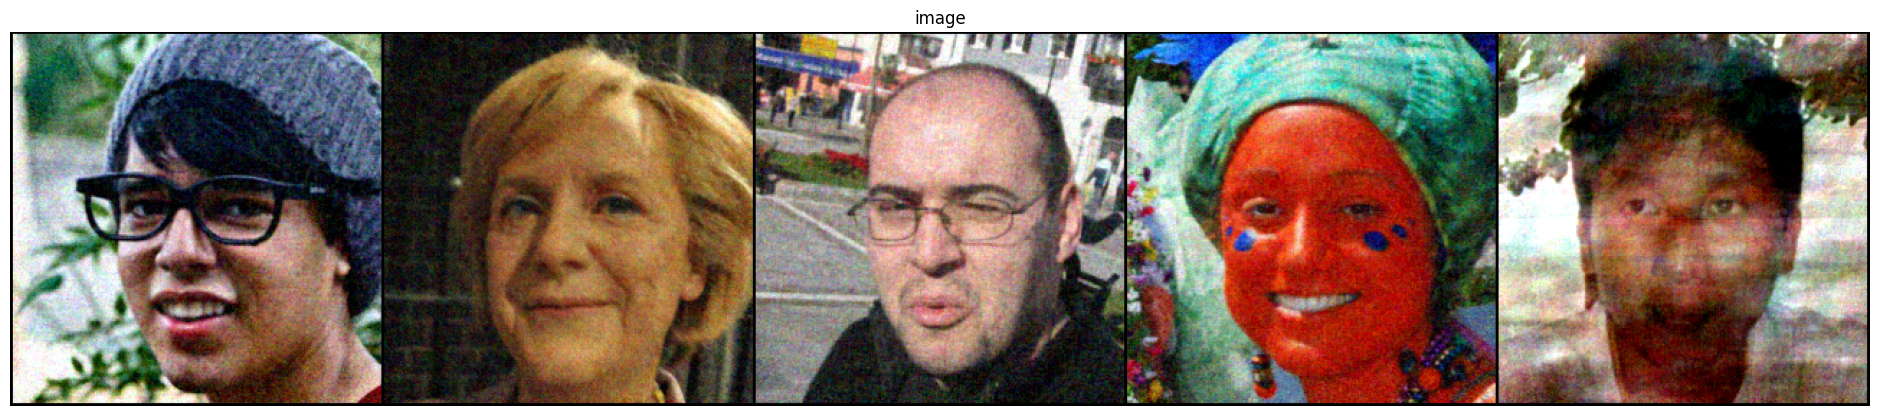

In [30]:
ours_norm = norm_image_01(x_final)
visualize_grid(x_final, nrow=10)

In [31]:
# PSNR 
psnr_value_ours = psnr(gt_norm, ours_norm, data_range=1.0, reduction='mean')
print("PSNR:", psnr_value_ours.item())

# SSIM
ssim_value_ours = ssim(gt_norm, ours_norm, data_range=1.0, reduction='mean')
print("SSIM:", ssim_value_ours.item())

# LPIPS 
lpips_fn = LPIPS(replace_pooling=True, reduction='mean')  #replace_pooling =True, suggested by LPIPS paper
lpips_value_ours = lpips_fn(gt_norm, ours_norm)
print("LPIPS:", lpips_value_ours.item())

PSNR: 22.76226043701172
SSIM: 0.5148566365242004
LPIPS: 0.3445794880390167


In [32]:
batch_size = 5
gt_dataset = TensorDataset(gt_norm)
ours_dataset = TensorDataset(ours_norm)

# gt_dl = DataLoader(gt_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dict)
ours_dl = DataLoader(ours_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dict)


fid_metric = FID().to(gt_norm.device)
# gt_feats = fid_metric.compute_feats(gt_dl)
ours_feats = fid_metric.compute_feats(ours_dl)

fid_value_ours = fid_metric(gt_feats, ours_feats)

print("FID Score =", fid_value_ours.item())

FID Score = 217.2126122130663


In [33]:

ours_loader = DataLoader(ours_norm, batch_size=5)

fid_ours = compute_fid(ours_loader, fake_loader)
print("FID:", fid_ours)

FID: 261.9267813873995


In [34]:
print("DAPS")
print("PSNR:", psnr_value.item())
print("SSIM:", ssim_value.item())
print("LPIPS:", lpips_value.item())
print("FID:", fid)

print("\nOURS")
print("PSNR:", psnr_value_ours.item())
print("SSIM:", ssim_value_ours.item())
print("LPIPS:", lpips_value_ours.item())
print("FID:", fid_ours)


DAPS
PSNR: 21.997772216796875
SSIM: 0.6028356552124023
LPIPS: 0.32474932074546814
FID: 279.8274325700811

OURS
PSNR: 22.76226043701172
SSIM: 0.5148566365242004
LPIPS: 0.3445794880390167
FID: 261.9267813873995
